In [1]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

dataDir = os.path.join("/content/drive/MyDrive/QReaserch/graph_coarsening/graph_coarsening/21_solving-vehicle-routing-problem-and-its-variants-using-quantum-computing_b/results")

data_Christofides_neal = pd.read_csv(os.path.join(dataDir, "neal", "CSPS_csvOutputFile_neal.csv"))
data_Christofides_leap = pd.read_csv(os.path.join(dataDir, "leap", "CSPS_csvOutputFile_leap.csv"))


Mounted at /content/drive


In [2]:
def flatten(x_array):
    """flateen array function"""
    flat = [item for sublist in x_array for item in sublist]
    return flat

def get_relative_values(data):
    """Get the data frame with the row data and calculate the relative cost and evaluation time"""
    cmt_instance_name = []
    ratio_cost = []
    nodes_number = []
    run_number = []
    coarsening_ratio = []

    nodes_num4CMT_instance = {'CMT01.xml': 51,
                              'CMT02.xml': 76,
                              'CMT03.xml': 101,
                              'CMT04.xml': 151,
                              'CMT05.xml': 200,
                              'CMT11.xml': 121,
                              'CMT12.xml': 101}

    for run in data['Run Number'].unique():
        for cmt_instance in data['cmtFileName'].unique():
            nodes = nodes_num4CMT_instance[cmt_instance]
            coarsening_ratio.append(data['Coarsening Rate'][(data['Run Number']==run) & (data['cmtFileName']==cmt_instance)].values)
            temp = data['Relative Cost'][(data['Run Number']==run) & (data['cmtFileName']==cmt_instance)].values
            if len(temp) != 0:
              ratio_cost.append(temp/temp[0])
              nodes_number.append([nodes]*len(temp))
              run_number.append([run]*len(temp))
              cmt_instance_name.append([cmt_instance]*len(temp))

    # Get the relative solve time
    ratio_time = []
    for run in data['Run Number'].unique():
        for nodes in data['Number of Nodes'].unique():
            temp = data['Solve Time'][(data['Run Number']==run) & (data['Number of Nodes']==nodes)].values
            if len(temp) != 0:
              ratio_time.append(temp/temp[0])

    cmt_instance_name = flatten(cmt_instance_name)
    ratio_cost = flatten(ratio_cost)
    nodes_number = flatten(nodes_number)
    run_number = flatten(run_number)
    ratio_time = flatten(ratio_time)
    coarsening_ratio = flatten(coarsening_ratio)

    relative_df = pd.DataFrame(list(zip(cmt_instance_name,coarsening_ratio,nodes_number, run_number,ratio_cost,ratio_time)), 
    columns =['cmtFileName', 'coarsening_ratio','nodes_number','run_number','ratio_cost','ratio_time'])
    return(relative_df)


In [3]:
relative_Christofides_neal_df = get_relative_values(data_Christofides_neal)
relative_Christofides_leap_df = get_relative_values(data_Christofides_leap)

print(relative_Christofides_neal_df.to_markdown())

|    | cmtFileName   |   coarsening_ratio |   nodes_number |   run_number |   ratio_cost |   ratio_time |
|---:|:--------------|-------------------:|---------------:|-------------:|-------------:|-------------:|
|  0 | CMT01.xml     |                1   |             51 |            0 |     1        |    1         |
|  1 | CMT01.xml     |                0.9 |             51 |            0 |     0.917693 |    0.68758   |
|  2 | CMT01.xml     |                0.7 |             51 |            0 |     0.776727 |    0.341577  |
|  3 | CMT01.xml     |                0.5 |             51 |            0 |     0.585036 |    0.138973  |
|  4 | CMT01.xml     |                0.3 |             51 |            0 |     0.406426 |    0.0546501 |
|  5 | CMT02.xml     |                1   |             76 |            0 |     1        |    1         |
|  6 | CMT02.xml     |                0.9 |             76 |            0 |     0.916161 |    0.719138  |
|  7 | CMT02.xml     |                0.7 |   

In [4]:
print(relative_Christofides_leap_df.to_markdown())

|     | cmtFileName   |   coarsening_ratio |   nodes_number |   run_number |   ratio_cost |   ratio_time |
|----:|:--------------|-------------------:|---------------:|-------------:|-------------:|-------------:|
|   0 | CMT01.xml     |                1   |             51 |            0 |     1        |    1         |
|   1 | CMT01.xml     |                0.9 |             51 |            0 |     0.917693 |    0.73645   |
|   2 | CMT01.xml     |                0.7 |             51 |            0 |     0.776727 |    0.415023  |
|   3 | CMT01.xml     |                0.5 |             51 |            0 |     0.585036 |    0.253122  |
|   4 | CMT01.xml     |                0.3 |             51 |            0 |     0.406426 |    0.238478  |
|   5 | CMT02.xml     |                1   |             76 |            0 |     1        |    1         |
|   6 | CMT02.xml     |                0.9 |             76 |            0 |     0.916161 |    0.716947  |
|   7 | CMT02.xml     |              

In [5]:
relative_Christofides_leap_df[90:]

,cmtFileName,coarsening_ratio,nodes_number,run_number,ratio_cost,ratio_time
90,CMT05.xml,1.0,200,2,1.000000,1.000000
91,CMT05.xml,0.9,200,2,0.909050,0.725203
92,CMT05.xml,0.7,200,2,0.730889,0.355446
93,CMT05.xml,0.5,200,2,0.567061,0.140007
94,CMT05.xml,0.3,200,2,0.396759,0.050714
95,CMT11.xml,1.0,121,2,1.000000,1.000000
96,CMT11.xml,0.9,121,2,0.886053,0.745793
97,CMT11.xml,0.7,121,2,0.661346,0.361182
98,CMT11.xml,0.5,121,2,0.470146,0.141982
99,CMT11.xml,0.3,121,2,0.285322,0.050382


In [6]:

def plot_results(df, filename):

    ratios = df['coarsening_ratio'].unique()
    ratios = sorted(ratios, reverse=True)
    ratio_label = [str(label) for label in  ratios]
    
    # collecting all the data as function of coarsening ratio
    data_cost = []
    for ratio in ratios:
        data_cost.append(df[df['coarsening_ratio']==ratio].ratio_cost.values)


    # collecting all the data as function of coarsening ratio
    data_time = []
    for ratio in ratios:
        data_time.append(df[df['coarsening_ratio']==ratio].ratio_time.values)

    fig = plt.figure(figsize=(20,6))
    ax = fig.add_subplot(1,2,1)

    ax.boxplot(data_time)

    # axis labels
    ax.set_xticklabels([*ratio_label], fontsize=18)
    ax.yaxis.set_tick_params(labelsize=18)

    # Adding title
    plt.title("Relative Evaluation time Function", fontsize=20)

    plt.ylabel('relative time', fontsize=18)
    plt.xlabel('coarsening ratio', fontsize=18)
    # plt.grid(True)


    ax = fig.add_subplot(1,2,2)
    # Creating plot
    ax.boxplot(data_cost)

    # axis labels
    ax.set_xticklabels([*ratio_label], fontsize=18)
    ax.yaxis.set_tick_params(labelsize=18)

    # Adding title
    plt.title("Relative Cost Function", fontsize=20)

    plt.ylabel('relative Cost', fontsize=18)
    plt.xlabel('coarsening ratio', fontsize=18)
    # plt.grid(True)

    plt.savefig(filename)  
    return()



()

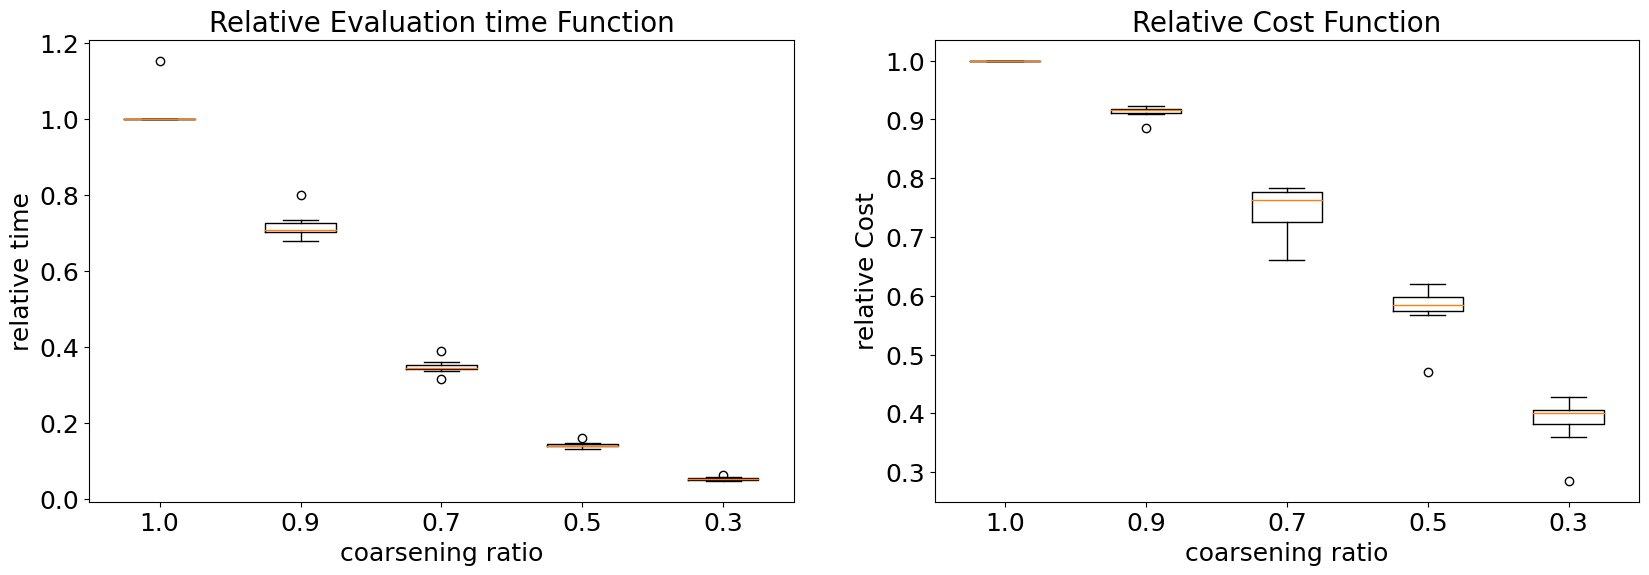

In [7]:
plot_results(relative_Christofides_neal_df, "relative_Christofides_neal_df.pdf")

()

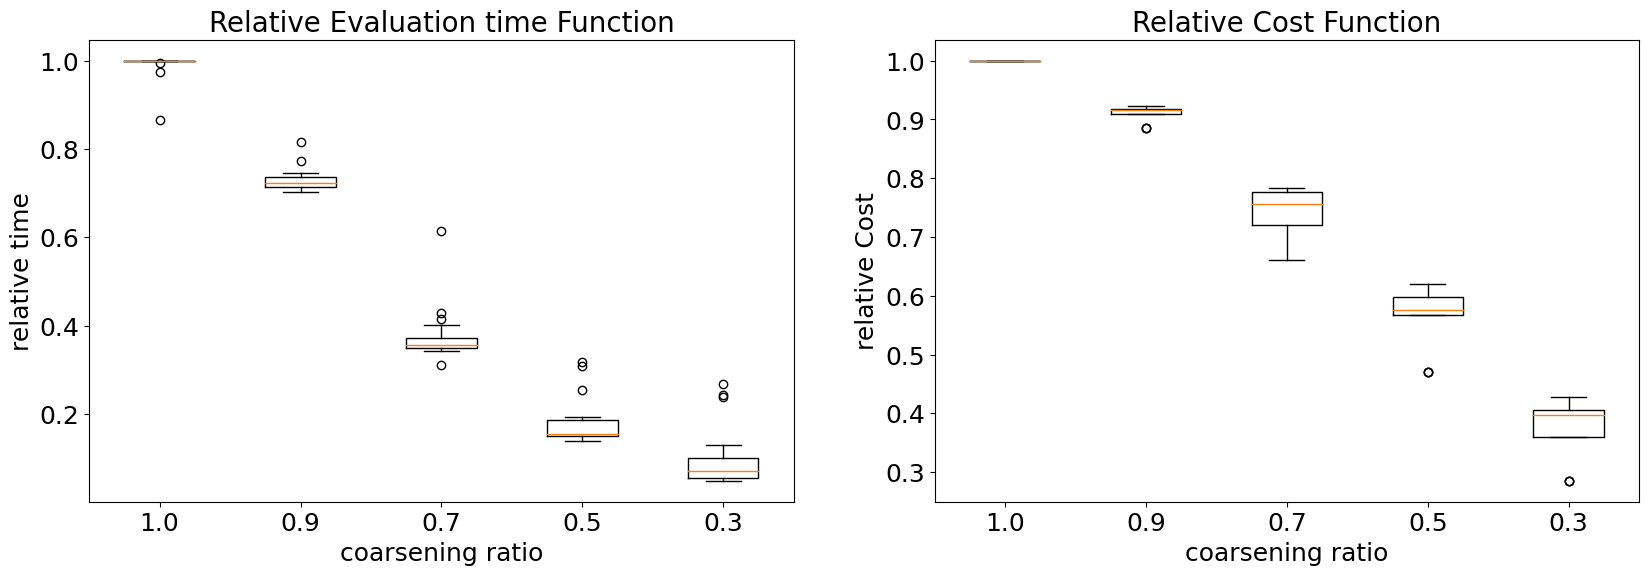

In [8]:

plot_results(relative_Christofides_leap_df, "relative_Christofides_leap_df.pdf")

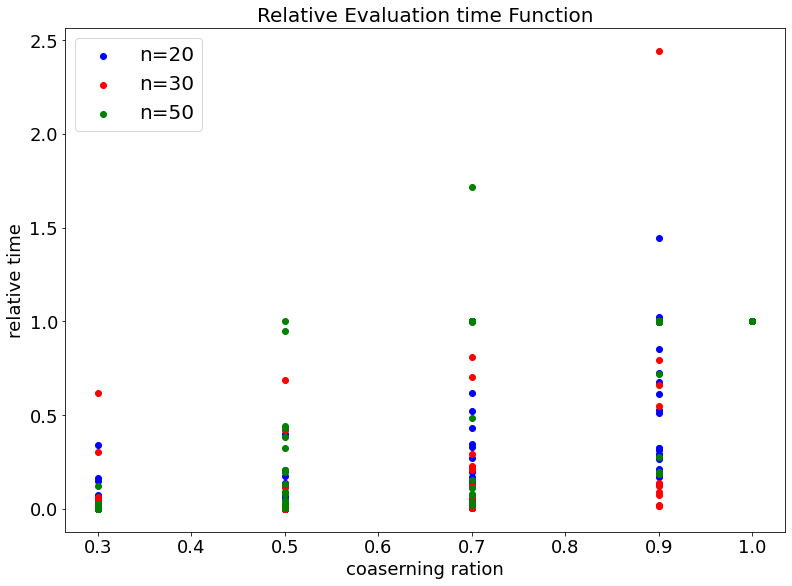

In [ ]:
fig = plt.figure(figsize =(10, 7))

ax = fig.add_axes([0, 0, 1, 1])
ax.scatter(relative_df[relative_df['nodes_number']==20].coarsening_ratio.values, relative_df[relative_df['nodes_number']==20].ratio_time.values, color='b', label='n=20')
ax.scatter(relative_df[relative_df['nodes_number']==30].coarsening_ratio.values, relative_df[relative_df['nodes_number']==30].ratio_time.values, color='r',label='n=30')
ax.scatter(relative_df[relative_df['nodes_number']==50].coarsening_ratio.values, relative_df[relative_df['nodes_number']==50].ratio_time.values, color='g', label='n=50')
ax.legend()

ax.xaxis.set_tick_params(labelsize=18)
ax.yaxis.set_tick_params(labelsize=18)

plt.legend(loc=2, prop={'size': 20})
plt.title("Relative Evaluation time Function", fontsize=20)

plt.ylabel('relative time', fontsize=18)
plt.xlabel('coaserning ration', fontsize=18)

# plt.legend({"N=20","N=30","N=50"},fontsize=20)
plt.show()

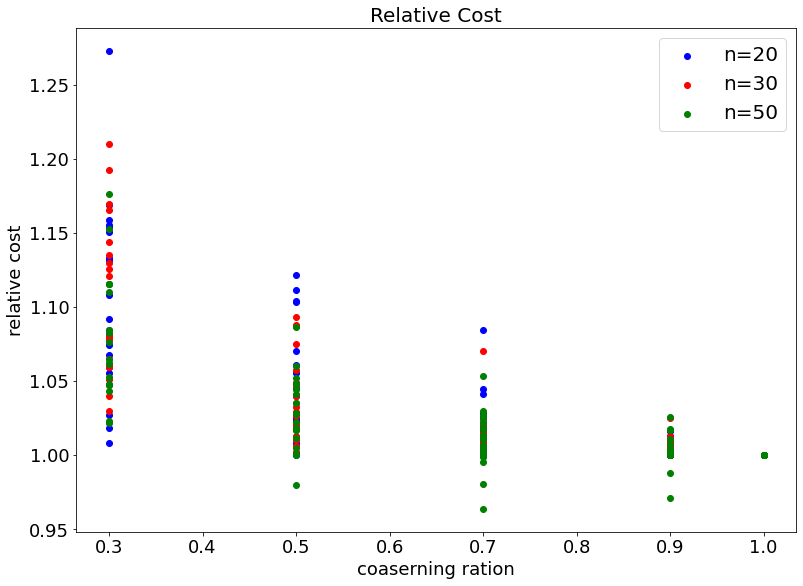

In [ ]:
fig = plt.figure(figsize =(10, 7))

ax = fig.add_axes([0, 0, 1, 1])
ax.scatter(relative_df[relative_df['nodes_number']==20].coarsening_ratio.values, relative_df[relative_df['nodes_number']==20].ratio_cost.values, color='b', label='n=20')
ax.scatter(relative_df[relative_df['nodes_number']==30].coarsening_ratio.values, relative_df[relative_df['nodes_number']==30].ratio_cost.values, color='r',label='n=30')
ax.scatter(relative_df[relative_df['nodes_number']==50].coarsening_ratio.values, relative_df[relative_df['nodes_number']==50].ratio_cost.values, color='g', label='n=50')
ax.legend()

ax.xaxis.set_tick_params(labelsize=18)
ax.yaxis.set_tick_params(labelsize=18)

plt.legend(loc=1, prop={'size': 20})
plt.title("Relative Cost", fontsize=20)

plt.ylabel('relative cost', fontsize=18)
plt.xlabel('coaserning ration', fontsize=18)

# plt.legend({"N=20","N=30","N=50"},fontsize=20)
plt.show()